# 02 光谱诊断与手动调参

这个 notebook 是当前主要的数据处理和调参入口，形式接近旧版 `legacy/spectral_diagnostics.ipynb`：先集中设置参数，再读取光谱、测量科学量、逐项画图，最后提供单条谱线的局部检查图。

批量读谱、谱线库、平滑、连续谱和质检规则主要调用 `src.spectral_pipeline`。Notebook 里保留的是方便手动调整的包装函数和可视化函数。

In [19]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from importlib import reload

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src import spectral_pipeline as sp
from src import spectral_notebook_tools as snt

ANALYSIS_DIR = PROJECT_ROOT / "output" / "analysis_pipeline"
FIG_DIR = ANALYSIS_DIR / "figures"

## 1. 配置和调参位置

常用调参只改这个 cell：

- `TARGETS`：空列表表示处理所有 `data/SN*/` 光谱。
- `TARGET_METADATA`：只放你手动确认的信息；默认不读 TNS catalog，也不读 `output/`。
- `REDSHIFT_MEASUREMENTS`：手动测得的宿主窄线红移表。多条光谱/多条谱线时，目标级红移取中位数并显示 scatter。
- `TARGET_LINES`：为某个目标手动覆盖要测的谱线；留空时按 SN 类型自动选择关键谱线。
- `AUTO_CLASSIFY_TYPES`：没有手动类型时，使用本地光谱经验粗分类结果给 02 自动选线。
- `LINE_PARAM_OVERRIDES`：按谱线、目标+谱线、目标+文件+谱线覆盖半宽、平滑窗口、连续谱边缘比例。
- `OUTPUT_TAG`：空字符串时自动使用当前目标名；`SAVE_PRODUCTS=True`/`SAVE_FIGURES=True` 只会覆盖同一 tag 的输出，不会覆盖其他目标的输出。
- 红移检查第 4 节里只改“选取的发射线”、“手动观测波长”和 `REDSHIFT_SPECTRUM_INDEX`。
- `CHECK_*`：控制最后的单条谱线局部检查图。

方法说明：本节只设置参数，不读取数据，也不运行任何拟合。

In [20]:
TARGETS = ["SN2026KID"]  # 例如 ["SN2026KID"]; 空列表表示全部目标

TARGET_METADATA = {
    # 只填自己确认的信息；不要从 data/tns_public_objects.csv 复制。
    # "SN2026KID": {"type": "SN II", "discoverydate": "2026-04-22 00:00:00"},
}

REDSHIFT_MEASUREMENTS = [
    # 建议优先用宿主星系窄发射线；不要默认用 SN 宽吸收线算宇宙学红移。
    {'target': 'SN2026KID', 'file': 'data/SN2026kid/SN2026kid_bfosc_20260426.fits', 'line': 'Halpha', 'kind': 'host/emission', 'rest_wave': 6562.8, 'observed_wave': 6573.963348940219},
]

TARGET_LINES = {
    # 留空时按 spec["type"] 自动选择；这里仅用于手动覆盖。
    # "SN2026KID": ["Halpha", "Hbeta", "FeII5169"],
    # "SN2026JLM": ["SiII6355", "CaIIHK", "SII5640"],
}

AUTO_CLASSIFY_TYPES = True  # 没有手动 type 时，用本地光谱经验粗分类来自动选线
AUTO_APPLY_ROUGH_Z = False  # 红移仍建议用第 4-5 节手动宿主窄线测量；不默认采用粗红移
AUTO_OVERWRITE_MANUAL_TYPE = False

LINE_HALF_WIDTH = 420.0
LINE_SMOOTH_WINDOW = 21
LINE_EDGE_FRACTION = 0.18
BB_WAVE_RANGE = (4200.0, 7600.0)
RAW_REFERENCE_LINES = ["CaIIHK", "Hgamma", "Hbeta", "FeII5169", "SII5640", "HeI5876", "SiII6355", "Halpha", "OI7774", "CaIINIR"]

LINE_PARAM_OVERRIDES = {
    # "SiII6355": {"half_width": 500.0},
    # ("SN2026KID", "Halpha"): {"half_width": 650.0, "smooth_window": 31},
    # ("SN2026JLM", "SN2026jlm_bfosc_20260510.fits", "SiII6355"): {"edge_fraction": 0.22},
}

SAVE_PRODUCTS = True  # 写出 CSV；同一 RUN_TAG 会覆盖，自动目标 tag 不会覆盖别的目标
SAVE_FIGURES = True  # 写出 PNG；同一 RUN_TAG 会覆盖，自动目标 tag 不会覆盖别的目标
PRODUCT_PREFIX = ""  # 例如 "trial" 可在目标 tag 前再加一层前缀
OUTPUT_TAG = ""  # 空字符串表示自动用当前目标名，例如 SN2026KID；也可手动填 "trial_SN2026KID"

DIAGNOSTIC_TARGET = None  # 图形诊断网格只看某个目标；None 表示全部
MAX_DIAGNOSTIC_PANELS = 12

REDSHIFT_CHECK_TARGET = None
REDSHIFT_HALF_WIDTH = 160.0

CHECK_TARGET = None
CHECK_LINE = None

### 按 SN 类型自动选择的关键科学谱线

这些谱线来自当前 `src.spectral_pipeline` 的默认规则，并参考了文献调研中 SNID/Superfit/DASH 分类、Type II 光谱多样性、Ia 大样本和去包层超新星数据集的常用诊断：

| 类型 | 自动测量的关键谱线 | 用途 |
|---|---|---|
| Ia | Si II 6355/5972, S II 5640, Ca II H&K/NIR, C II 6580 | 分类确认、Si II 速度与 pEW、正常/高速 Ia 和碳线检查 |
| II | H alpha/beta/gamma, Fe II 5169/5018/4924, Sc II 5527, Ca II H&K/NIR | 氢线与 Fe II 速度、平台期谱线演化、Type II 文献比较 |
| IIn | H alpha/beta/gamma, Fe II 5169, Ca II H&K | 窄/宽氢发射和相互作用迹象的初筛 |
| IIb | H alpha/beta, He I 5876/6678/7065, Fe II 5169, Ca II H&K/NIR | 氢到氦的转变、IIb/Ib 子型判断 |
| Ib | He I 5876/6678/7065, Ca II H&K/NIR, O I 7774 | 氦线识别、Ib/Ic 区分 |
| Ic/Ic-BL | O I 7774, Ca II H&K/NIR, Fe II 5169, C II 6580 | 无氢氦谱线、O/Ca/Fe 速度与宽线候选检查 |

`TARGET_LINES` 留空时会按这些规则自动选择；若某个目标需要更保守或更窄的线表，可以在配置区手动覆盖。

## 2. 导入 notebook 工具函数

大段调参辅助函数已经放到 `src/spectral_notebook_tools.py`，这里保持 notebook 简洁。你修改 `src/` 后可以重新运行这个 cell。

方法说明：本节只导入/重载函数，不运行任何拟合。

In [21]:
reload(snt)
print("Loaded src.spectral_notebook_tools")

Loaded src.spectral_notebook_tools


## 3. 读取本地观测光谱

这里只读取 `data/` 下的一维 FITS 光谱，不读 `data/tns_public_objects.csv`，也不读 `output/`。因此初始红移通常是空的，除非你在 `TARGET_METADATA` 里手动填了 `z`。

方法说明：本步不做物理拟合，也不做红移校正；图中光谱只用 Savitzky-Golay 作轻微预平滑以便显示。Savitzky-Golay 的含义是在移动窗口内做低阶多项式拟合，并用该窗口中心的拟合值替代原始值。竖虚线是 `RAW_REFERENCE_LINES` 的未校准静止波长参考线，直接画在观测波长轴上，没有乘 `(1+z)`，只用于找线。

,target,file,date_obs,phase_days,type,z,host,n_pix,wave_min,wave_max,flux_median,exptime,instrument,setup
0,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,,NaN,,1861,3727.929497,8857.409114,7.767351e-15,2400.0,BFOSC,slit23_385LP_NewG4
1,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,2026-04-27 15:05:27,NaN,,NaN,,1861,3728.500379,8859.653799,1.450921e-15,1500.0,BFOSC,slit23_385LP_NewG4
2,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,2026-05-08 16:27:20,NaN,,NaN,,1861,3735.483487,8864.023490,1.801202e-15,3000.0,BFOSC,slit23_385LP_NewG4


z_source 说明：unset=未设置；manual_config=来自 TARGET_METADATA；manual=来自后面手动测红移。
未处理的多历元光谱序列图：只用原始观测波长和本地 FITS flux，不应用红移、类型或自动选线。
saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/raw_spectral_sequence_SN2026KID.png


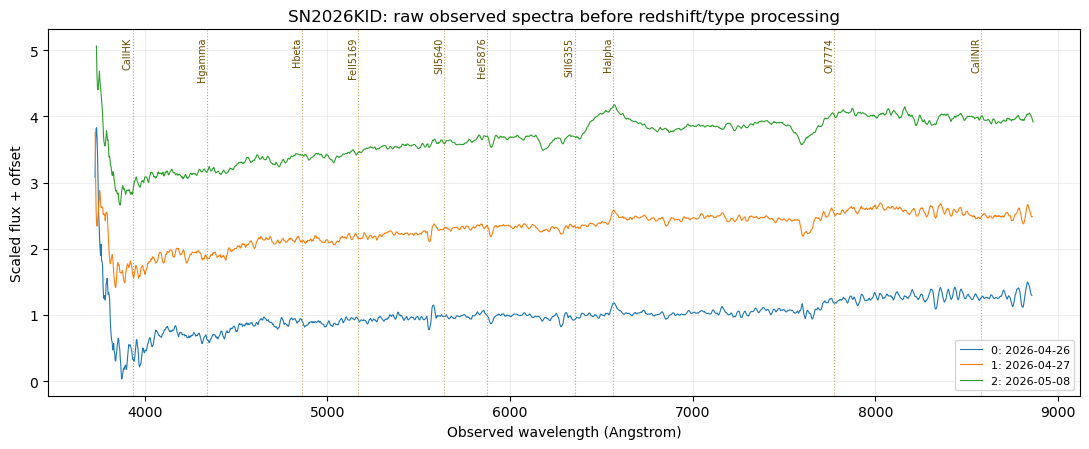

In [22]:
spectra_raw, skipped_fits = snt.load_observed_spectra(PROJECT_ROOT, TARGET_METADATA)
if TARGETS:
    wanted = {snt.target_key(t) for t in TARGETS}
    spectra_raw = [spec for spec in spectra_raw if spec["target"] in wanted]

if not spectra_raw:
    raise RuntimeError("没有找到可处理的一维 FITS 光谱。请检查 data/SN*/ 下的文件。")

summary_raw = sp.build_summary(spectra_raw)
display(summary_raw)
print("z_source 说明：unset=未设置；manual_config=来自 TARGET_METADATA；manual=来自后面手动测红移。")
if not skipped_fits.empty:
    print("跳过的 FITS：")
    display(skipped_fits)

print("未处理的多历元光谱序列图：只用原始观测波长和本地 FITS flux，不应用红移、类型或自动选线。")
for target in sorted(summary_raw["target"].unique()):
    raw_sequence_fig = snt.plot_raw_spectral_sequence(
        target,
        spectra_raw,
        fig_dir=FIG_DIR,
        save_figures=SAVE_FIGURES,
        reference_lines=RAW_REFERENCE_LINES,
    )
    snt.show_figure(raw_sequence_fig)

## 4. 手动测红移：局部放大关键谱线

这一步只建议用于宿主星系窄发射线，例如 Halpha、Hbeta、[O III]。超新星自身的宽吸收线会被膨胀速度蓝移，不能直接当作宇宙学红移。

在下面的 code cell 顶部只改 `SELECTED_EMISSION_LINE`、`MANUAL_OBSERVED_WAVE` 和 `REDSHIFT_SPECTRUM_INDEX`。`z_guess` 会优先由手动波长推断；手动波长为空时，再用已有 `REDSHIFT_MEASUREMENTS` 或已设置的目标红移。

如果一个目标有多条光谱，建议在 `REDSHIFT_MEASUREMENTS` 里填多条记录；后面会按目标取中位数红移，并显示 scatter。

方法说明：本节只用于宿主窄发射线的红移复核，不使用第 7 节的超新星宽吸收线高斯拟合。局部窗口先用 Savitzky-Golay 做移动窗口低阶多项式预平滑；然后在窗口左右两端各取一段谱的中位数，连接这两个中位数点，得到一条局部线性连续谱；最后用 `flux / continuum` 归一化。绿线是自动取峰/取谷位置；紫线是手动或最终采用位置。`z_preview` 返回绿线自动红移，`redshift_plot["adopted_z"]` 是紫线红移。TNS 红移只打印作外部参考，不参与本 notebook 的红移采用。

,spectrum_index,target,date_obs,file,z,type
0,0,SN2026KID,2026-04-26 13:42:30,data/SN2026kid/SN2026kid_bfosc_20260426.fits,NaN,
1,1,SN2026KID,2026-04-27 15:05:27,data/SN2026kid/SN2026kid_bfosc_20260427.fits,NaN,
2,2,SN2026KID,2026-05-08 16:27:20,data/SN2026kid/SN2026kid_bfosc_20260508.fits,NaN,


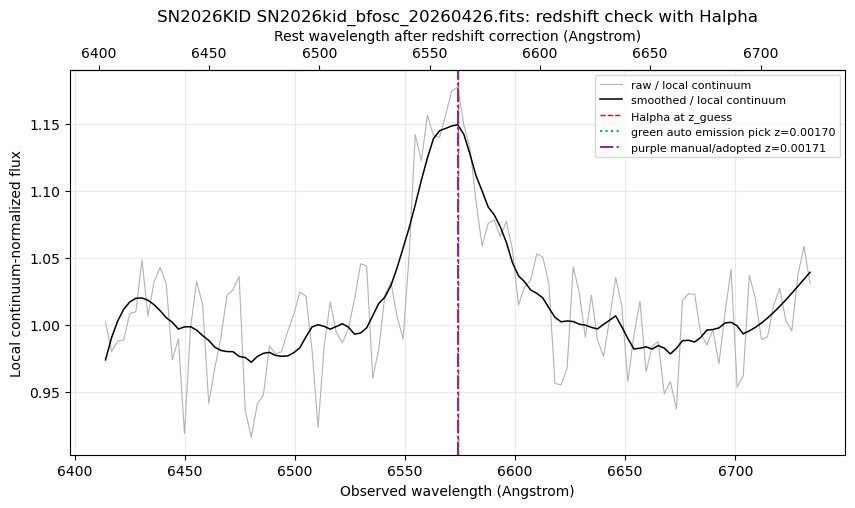

line = Halpha, rest_wave = 6562.800 A
plot z_guess = 0.001707
TNS/public-catalog reference z = 0.001700 (ok; not used in calculation)
TNS/public-catalog type = SN II
auto line z = 0.001701
auto line lambda = 6573.963 A
绿线调整合理后，请将一下内容填入 REDSHIFT_MEASUREMENTS
{'target': 'SN2026KID', 'file': 'data/SN2026kid/SN2026kid_bfosc_20260426.fits', 'line': 'Halpha', 'kind': 'host/emission', 'rest_wave': 6562.8, 'observed_wave': 6573.963348940219}


In [23]:
# 本 cell 通常只需要改这三项。
SELECTED_EMISSION_LINE = "Halpha"  # 可选示例：Halpha, Hbeta, OIII5007, OIII4959, SII6716
MANUAL_OBSERVED_WAVE = 6574  # 看图后填观测波长，例如 6701.2；第一次看图可先保留 None
REDSHIFT_SPECTRUM_INDEX = 0  # 先看下面的 spectrum_index 表，再改这里选择第几条光谱

redshift_check_target = summary_raw.iloc[0]["target"] if REDSHIFT_CHECK_TARGET is None else REDSHIFT_CHECK_TARGET
redshift_rest_wave = snt.line_rest_wave(SELECTED_EMISSION_LINE)
redshift_z_guess = snt.redshift_guess_for_line(
    spectra_raw,
    redshift_check_target,
    SELECTED_EMISSION_LINE,
    redshift_rest_wave,
    manual_observed_wave=MANUAL_OBSERVED_WAVE,
    measurements=REDSHIFT_MEASUREMENTS,
)
redshift_tns_ref = snt.tns_redshift_reference(PROJECT_ROOT, redshift_check_target)

redshift_items = sorted(
    [spec for spec in spectra_raw if spec["target"] == snt.target_key(redshift_check_target)],
    key=lambda spec: pd.Timestamp.max if pd.isna(spec["date_obs"]) else spec["date_obs"],
)
display(snt.spectrum_choice_table(spectra_raw, redshift_check_target))
redshift_spec = redshift_items[int(REDSHIFT_SPECTRUM_INDEX)]
redshift_plot, z_preview = snt.plot_redshift_zoom(
    redshift_spec,
    SELECTED_EMISSION_LINE,
    rest_wave=redshift_rest_wave,
    z_guess=redshift_z_guess,
    half_width=REDSHIFT_HALF_WIDTH,
    manual_observed_wave=MANUAL_OBSERVED_WAVE,
    mode="emission",
)
snt.show_figure(redshift_plot.get("figure"))
# Keep this output concise; do not expand back to the verbose purple/manual-adopted two-record printout.
print(f"line = {SELECTED_EMISSION_LINE}, rest_wave = {redshift_rest_wave:.3f} A")
print(f"plot z_guess = {redshift_z_guess:.6f}")
try:
    if np.isfinite(redshift_tns_ref["z_tns"]):
        print(f"TNS/public-catalog reference z = {redshift_tns_ref['z_tns']:.6f} ({redshift_tns_ref['status']}; not used in calculation)")
    else:
        print(f"TNS/public-catalog reference z = unavailable ({redshift_tns_ref['status']}; not used in calculation)")
    if redshift_tns_ref.get("type_tns"):
        print(f"TNS/public-catalog type = {redshift_tns_ref['type_tns']}")
except Exception:
    print("未找到 TNS 数据")
print(f"auto line z = {z_preview:.6f}")
print(f"auto line lambda = {redshift_plot['auto_wave']:.3f} A")
print("绿线调整合理后，请将一下内容填入 REDSHIFT_MEASUREMENTS")
print({
    "target": redshift_spec["target"],
    "file": redshift_spec["file"],
    "line": SELECTED_EMISSION_LINE,
    "kind": "host/emission",
    "rest_wave": redshift_rest_wave,
    "observed_wave": redshift_plot["auto_wave"],
})

## 5. 汇总手动红移，并用本地光谱粗分类自动选线

方法说明：手动红移按目标取中位数，scatter 只作为多条线/多历元一致性的提示。粗分类不是物理拟合；它把局部线性连续谱归一化后的关键吸收线强度、宿主窄发射线启发式红移，以及已有 Superfit/DASH 模板结果合并成类型建议。默认不把粗分类红移写入科学测量。

In [24]:
redshift_table, redshift_summary, MANUAL_REDSHIFT_BY_TARGET = snt.redshift_table_from_measurements(REDSHIFT_MEASUREMENTS)
display(redshift_table)
display(redshift_summary)

spectra = snt.apply_redshift_overrides(spectra_raw, MANUAL_REDSHIFT_BY_TARGET)

rough_spectrum_table, rough_target_table, rough_feature_table = snt.rough_classify_spectra(spectra)
template_spectrum_table, template_target_table = snt.summarize_local_template_classifications(PROJECT_ROOT)
active_targets = {spec["target"] for spec in spectra}
if not template_target_table.empty:
    template_target_table = template_target_table[template_target_table["target"].isin(active_targets)].reset_index(drop=True)
if not template_spectrum_table.empty:
    template_spectrum_table = template_spectrum_table[template_spectrum_table["target"].isin(active_targets)].reset_index(drop=True)
classification_target_table = snt.combine_template_and_rough_classifications(template_target_table, rough_target_table)
if AUTO_CLASSIFY_TYPES:
    spectra = snt.apply_classification_context_to_spectra(
        spectra,
        classification_target_table,
        apply_type=True,
        apply_z=AUTO_APPLY_ROUGH_Z,
        overwrite_existing_type=AUTO_OVERWRITE_MANUAL_TYPE,
    )

summary = sp.build_summary(spectra)
display(summary)
display(classification_target_table)
display(template_target_table)
display(rough_target_table)
display(snt.selected_line_plan(spectra, TARGET_LINES))

RUN_TAG = snt.analysis_output_tag(summary[["target"]], OUTPUT_TAG)
print(f"analysis output tag = {RUN_TAG}")

,target,file,line,kind,rest_wave,observed_wave,z,note
0,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,Halpha,host/emission,6562.8,6573.963349,0.001701,


,target,z_manual,z_scatter,n_lines
0,SN2026KID,0.001701,NaN,1


,target,file,date_obs,phase_days,type,z,host,n_pix,wave_min,wave_max,flux_median,exptime,instrument,setup
0,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,,1861,3727.929497,8857.409114,7.767351e-15,2400.0,BFOSC,slit23_385LP_NewG4
1,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,2026-04-27 15:05:27,NaN,SN II,0.001701,,1861,3728.500379,8859.653799,1.450921e-15,1500.0,BFOSC,slit23_385LP_NewG4
2,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,2026-05-08 16:27:20,NaN,SN II,0.001701,,1861,3735.483487,8864.023490,1.801202e-15,3000.0,BFOSC,slit23_385LP_NewG4


,target,adopted_type,type_source,type_confidence,template_type,rough_type,template_z_median,rough_z_median,selected_lines
0,SN2026KID,SN II,"local_template:DASH, Superfit",0.59343,SN II,SN II,0.00155,0.002,"Halpha, Hbeta, Hgamma, FeII5169, FeII5018, FeI..."


,target,template_type,template_type_confidence,template_z_median,n_template_results,template_votes,method
0,SN2026KID,SN II,0.59343,0.00155,6,SN II:0.88; SN Ic:0.40; SN IIb:0.20,"DASH, Superfit"


,target,rough_type,rough_type_confidence,n_spectra,rough_z_median,rough_z_scatter,rough_velocity_median_kms,type_votes,selected_lines
0,SN2026KID,SN II,0.399907,3,0.002,0.039694,18800.353484,SN II:0.40; SN Ia:0.39; Unclassified:0.30,"Halpha, Hbeta, Hgamma, FeII5169, FeII5018, FeI..."


,target,type,type_source,selected_lines
0,SN2026KID,SN II,"local_template:DASH, Superfit","Halpha, Hbeta, Hgamma, FeII5169, FeII5018, FeI..."


analysis output tag = SN2026KID


## 6. 多历元光谱序列

下轴是观测波长，上轴是按当前目标红移换算后的静止系波长。谱线竖线画在观测波长位置，即 `rest_wave * (1 + z)`；如果目标还没有红移，就只能暂时画在静止波长位置。

方法说明：本步只是可视化，没有额外拟合；光谱为显示目的用 Savitzky-Golay 平滑和中位数尺度归一，谱线位置只由第 5 节采用的 `z` 换算。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/spectral_sequence_SN2026KID.png


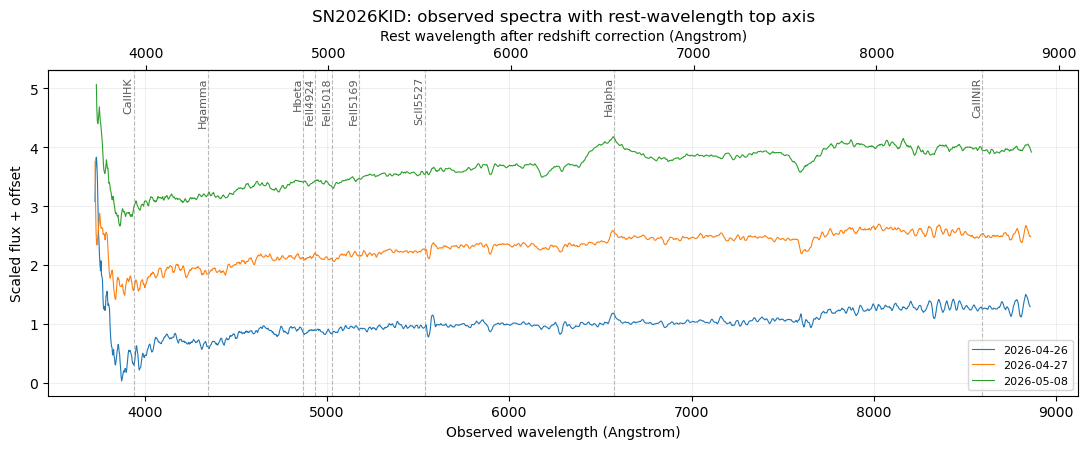

In [25]:
for target in sorted(summary["target"].unique()):
    sequence_fig = snt.plot_spectral_sequence_dual_axis(
        target,
        spectra,
        target_lines=TARGET_LINES,
        fig_dir=FIG_DIR,
        save_figures=SAVE_FIGURES,
    )
    snt.show_figure(sequence_fig)

## 7. 批量测量谱线、黑体颜色温度和宿主线

这一步使用第 5 节得到的手动红移。如果某个目标还没有红移，速度和静止系谱线测量只是占位结果，不应写入科学结论。

实际测量的谱线由第 5 节的 `selected_line_plan` 决定：`TARGET_LINES` 有手动覆盖时优先用它，否则按手动类型或自动粗分类类型选择关键谱线。

方法说明：谱线测量先转到当前静止系，再用 Savitzky-Golay 移动窗口低阶多项式预平滑，并用局部线性连续谱归一化；随后直接在归一化谱上拟合吸收型高斯，最终的吸收中心 `abs_wave`、速度 `velocity_kms`、线深 `depth` 和 `FWHM_A` 都来自该高斯拟合。pEW 仍由 `1 - flux/continuum` 的正面积直接积分，不改成高斯面积。黑体颜色温度用 Planck 黑体谱做非线性最小二乘拟合。宿主线指标用局部中位数连续谱和 robust noise，不做高斯拟合。

In [26]:
measure_kwargs = dict(
    line_half_width=LINE_HALF_WIDTH,
    line_smooth_window=LINE_SMOOTH_WINDOW,
    line_edge_fraction=LINE_EDGE_FRACTION,
    line_param_overrides=LINE_PARAM_OVERRIDES,
)

summary, line_df, line_qc, bb_df, host_lines, host_summary, target_status = snt.measure_all_features(
    spectra,
    target_lines=TARGET_LINES,
    bb_wave_range=BB_WAVE_RANGE,
    **measure_kwargs,
)

display(target_status)
display(line_qc[["target", "file", "line", "fit_method", "abs_wave", "velocity_kms", "velocity_err_kms", "pEW_A", "FWHM_A", "FWHM_err_A", "depth", "fit_center_err_A", "fit_sigma_A", "fit_sigma_err_A", "fit_depth_err", "fit_chi2_red", "extrema_wave_A", "extrema_depth", "qc_flag", "qc_note"]].head(20))

,target,type,z,n_spectra,date_start,date_end,phase_min_days,phase_max_days,adopted_line_measurements,needs_visual_checks,adopted_lines,host_lines,rough_EBV_host_mag,recommended_analysis
0,SN2026KID,SN II,0.001701,3,2026-04-26 13:42:30,2026-05-08 16:27:20,NaN,NaN,5,15,"FeII5169, Halpha","Halpha, NII6583, NaID5892, OII3727, SII6716",NaN,Type II: use Fe II/H velocities and pEW; compa...


,target,file,line,fit_method,abs_wave,velocity_kms,velocity_err_kms,pEW_A,FWHM_A,FWHM_err_A,depth,fit_center_err_A,fit_sigma_A,fit_sigma_err_A,fit_depth_err,fit_chi2_red,extrema_wave_A,extrema_depth,qc_flag,qc_note
0,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,CaIIHK,gaussian_absorption,3922.229233,874.202229,766.894903,181.135825,256.326268,48.623431,1.332484,10.062743,108.851746,20.648470,0.261598,4.873902,3878.525839,0.915659,check,secondary line; use only after visual inspecti...
1,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,CaIIHK,gaussian_absorption,3911.801185,1668.937550,861.059274,211.270373,338.998411,76.158204,1.278571,11.298312,143.959373,32.341412,0.394172,1.353089,3870.884959,0.789985,check,secondary line; use only after visual inspection
2,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,CaIIHK,gaussian_absorption,3916.684600,1296.766082,785.697220,225.312601,245.040624,50.640970,1.396626,10.309456,104.059174,21.505240,0.322081,6.631596,3850.254490,0.941063,check,secondary line; use only after visual inspection
3,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,CaIINIR,gaussian_absorption,NaN,NaN,NaN,9.993351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8316.525785,0.093527,reject,fit failed: center hit fit bound
4,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,CaIINIR,gaussian_absorption,NaN,NaN,NaN,10.098799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8549.931076,0.061835,reject,fit failed: center hit fit bound
5,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,CaIINIR,gaussian_absorption,8270.694013,10773.727663,135.807644,8.146045,108.618404,13.695060,0.094293,3.886335,46.125990,5.815757,0.008631,0.581640,8301.204474,0.061513,check,secondary line; use only after visual inspection
6,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,FeII4924,gaussian_absorption,4712.357657,12885.617011,117.194389,11.071375,25.661601,4.644070,0.103334,1.924882,10.897479,1.972155,0.015931,0.447095,4715.468757,0.088934,check,secondary line; use only after visual inspection
7,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,FeII4924,gaussian_absorption,4517.603403,24743.020862,855.418340,8.362254,134.242305,38.815377,0.214140,14.049986,57.007459,16.483373,0.080629,16.251991,4504.304975,0.051344,check,secondary line; use only after visual inspection
8,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,FeII4924,gaussian_absorption,4723.834455,12186.864470,118.635857,41.424057,70.724445,4.931988,0.162359,1.948558,30.033907,2.094423,0.009278,0.923577,4720.075266,0.188962,check,secondary line; use only after visual inspection
9,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,FeII5018,gaussian_absorption,4710.880999,18348.338007,99.549572,21.794510,33.257948,4.178009,0.116591,1.666285,14.123350,1.774237,0.012150,2.033748,4715.468757,0.113209,check,secondary line; use only after visual inspection


## 8. 谱线局部诊断图：中心、吸收谷、拟合和 pEW 区域

方法说明：每个谱线面板分上下两行。上图显示原始 flux、Savitzky-Golay 预平滑后的 flux，以及橙色局部线性连续谱；下图显示 `flux / continuum` 后的归一化谱。紫色线是本次测量实际使用的高斯吸收拟合，绿色线是高斯中心，灰色细线可对照旧的极值位置。浅紫色区域是 pEW 积分区域，即归一化谱中 `1 - flux/continuum` 的正面积；它不是误差带或高斯置信区间。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/SN2026KID_line_diagnostics_grid.png


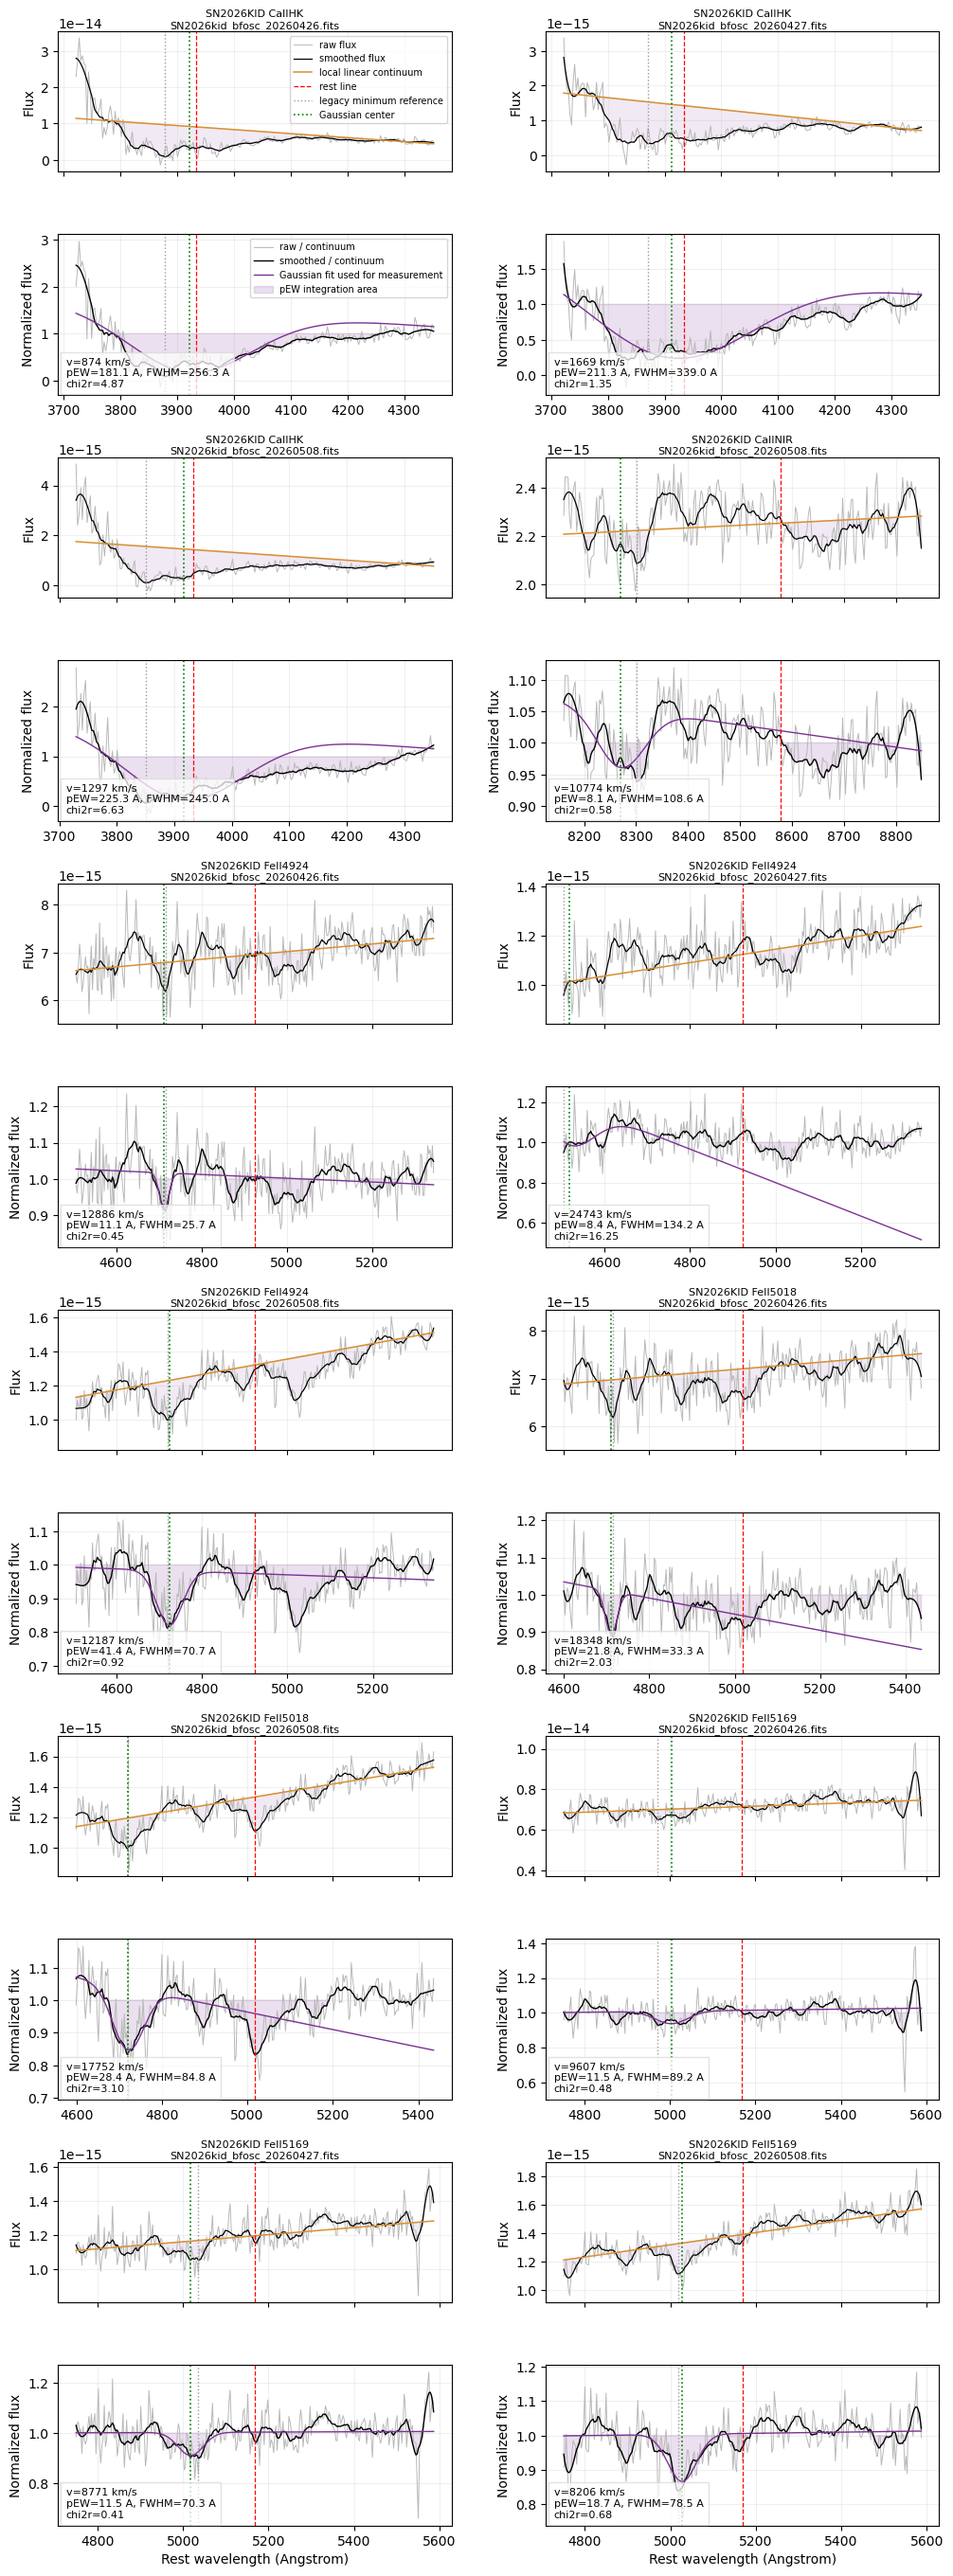

In [27]:
line_diagnostics_fig = snt.plot_line_diagnostics_grid(
    spectra,
    line_qc,
    target=DIAGNOSTIC_TARGET,
    max_panels=MAX_DIAGNOSTIC_PANELS,
    fig_dir=FIG_DIR,
    save_figures=SAVE_FIGURES,
    filename_tag=RUN_TAG,
    **measure_kwargs,
)
snt.show_figure(line_diagnostics_fig)

## 9. 黑体连续谱拟合图

方法说明：先取 `BB_WAVE_RANGE` 内的静止系光谱，平滑后做简单背景偏移和归一化，再用 Planck `B_lambda(T)` 黑体谱作非线性最小二乘拟合；输出的是颜色温度 proxy，不是完整辐射传输温度。图的标题分两行显示，只有最底行显示横坐标标题，避免标题与横坐标重叠。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/SN2026KID_blackbody_fit_grid.png


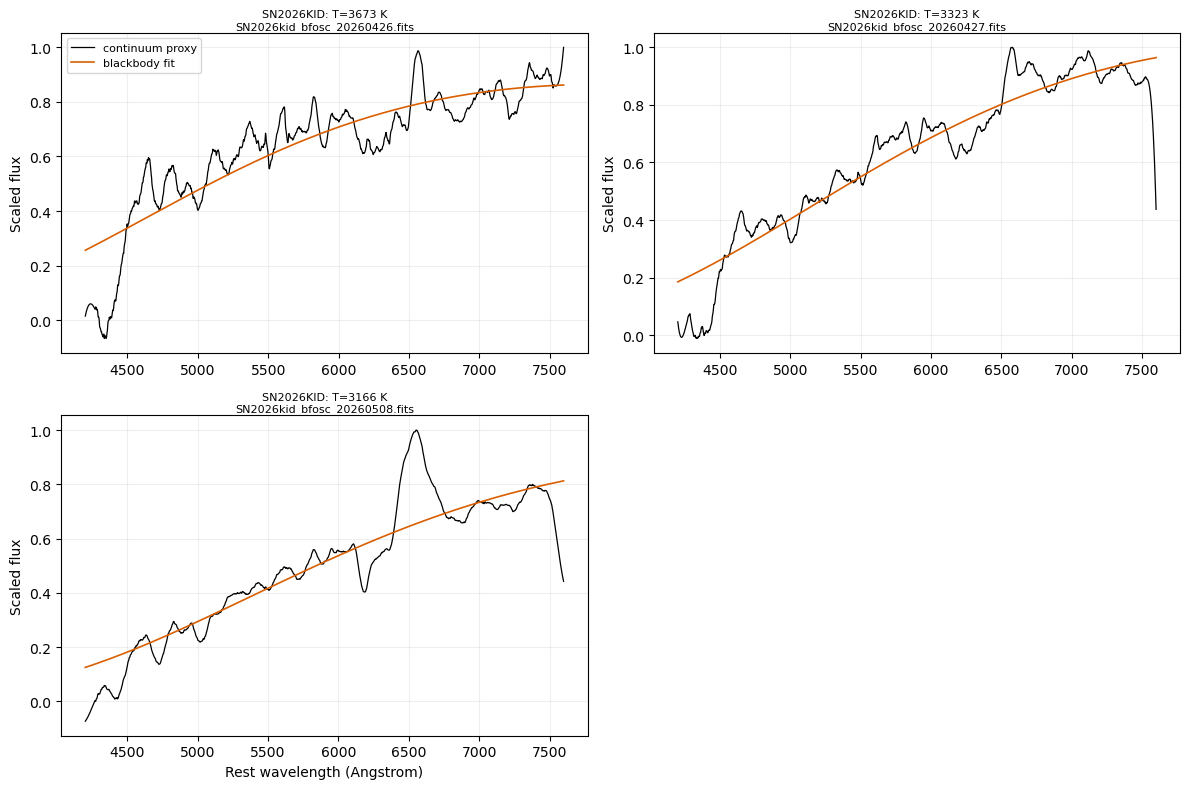

In [28]:
blackbody_fit_fig = snt.plot_blackbody_fit_grid(
    spectra,
    target=DIAGNOSTIC_TARGET,
    wave_range=BB_WAVE_RANGE,
    fig_dir=FIG_DIR,
    save_figures=SAVE_FIGURES,
    filename_tag=RUN_TAG,
)
snt.show_figure(blackbody_fit_fig)

## 10. 科学量图：谱线速度

方法说明：本步只绘制第 7 节已经测出的速度，不再做新拟合。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/SN2026KID_line_velocity_evolution.png


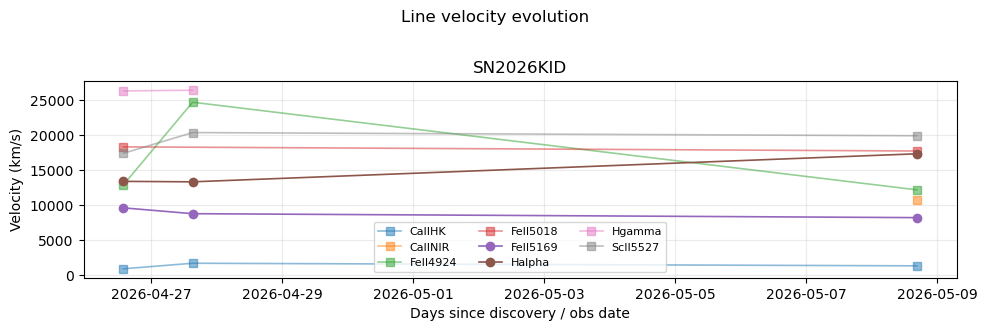

In [29]:
velocity_fig = snt.plot_quantity_by_target(line_qc, "velocity_kms", "Velocity (km/s)", "Line velocity evolution", snt.tagged_filename("line_velocity_evolution.png", RUN_TAG), FIG_DIR, save_figures=SAVE_FIGURES)
snt.show_figure(velocity_fig)

## 11. 科学量图：pseudo-equivalent width

方法说明：本步只绘制第 7 节由局部线性连续谱归一化后积分得到的 pEW，不再做新拟合。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/SN2026KID_pew_evolution.png


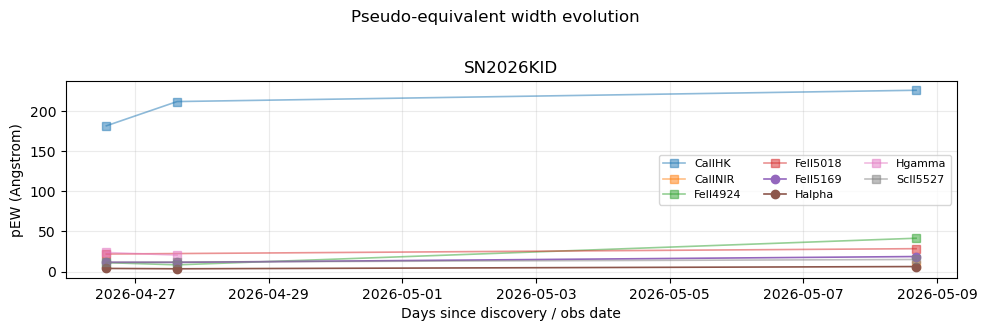

In [30]:
pew_fig = snt.plot_quantity_by_target(line_qc, "pEW_A", "pEW (Angstrom)", "Pseudo-equivalent width evolution", snt.tagged_filename("pew_evolution.png", RUN_TAG), FIG_DIR, save_figures=SAVE_FIGURES)
snt.show_figure(pew_fig)

## 12. 科学量图：FWHM

方法说明：本步只绘制第 7 节由高斯拟合 sigma 换算得到的 FWHM，不再做新拟合。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/SN2026KID_fwhm_evolution.png


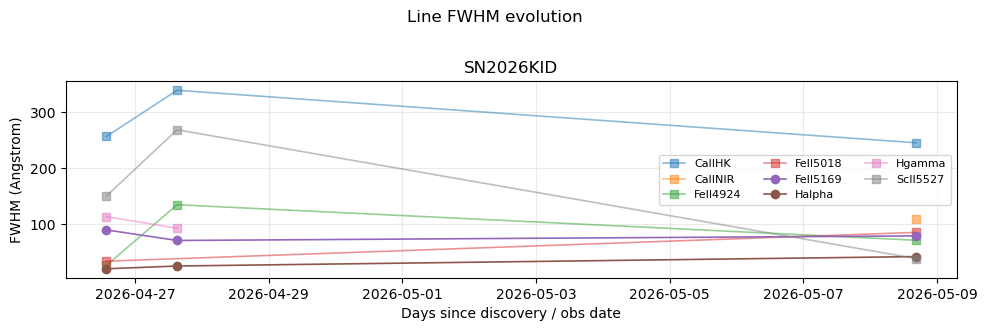

In [31]:
fwhm_fig = snt.plot_quantity_by_target(line_qc, "FWHM_A", "FWHM (Angstrom)", "Line FWHM evolution", snt.tagged_filename("fwhm_evolution.png", RUN_TAG), FIG_DIR, save_figures=SAVE_FIGURES)
snt.show_figure(fwhm_fig)

## 13. 科学量图：线深

方法说明：本步只绘制第 7 节高斯拟合得到的线深，不再做新拟合。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/SN2026KID_line_depth_evolution.png


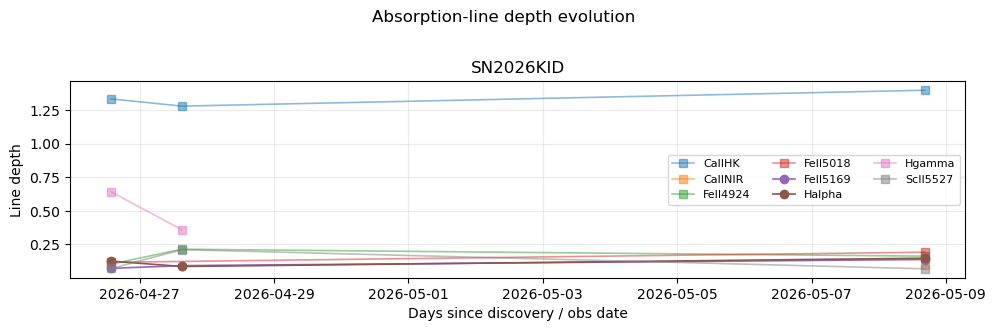

In [32]:
depth_fig = snt.plot_quantity_by_target(line_qc, "depth", "Line depth", "Absorption-line depth evolution", snt.tagged_filename("line_depth_evolution.png", RUN_TAG), FIG_DIR, save_figures=SAVE_FIGURES)
snt.show_figure(depth_fig)

## 14. 科学量图：连续谱黑体颜色温度

方法说明：本步只把第 7/9 节 Planck 黑体谱拟合得到的颜色温度画成演化图，不再做新拟合。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/SN2026KID_blackbody_temperature.png


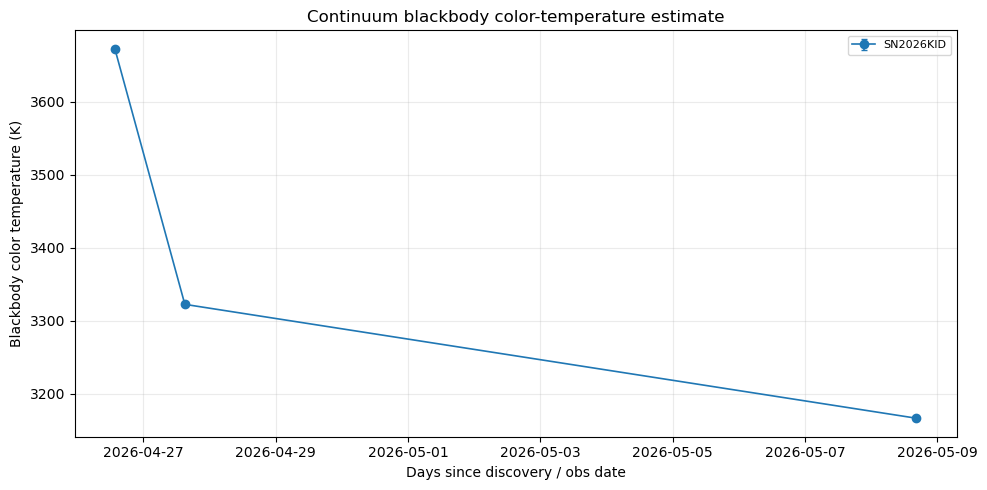

,target,file,date_obs,phase_days,type,z,T_bb_K,T_err_K,status
0,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,3672.849971,7.464315e-31,ok
1,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,2026-04-27 15:05:27,NaN,SN II,0.001701,3322.531062,2.766978e-30,ok
2,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,2026-05-08 16:27:20,NaN,SN II,0.001701,3166.386744,5.332940e-30,ok


In [33]:
ok_bb = bb_df[bb_df["status"].eq("ok")].copy()
if ok_bb.empty:
    print("没有成功的黑体颜色温度拟合。")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for target, group in ok_bb.groupby("target"):
        x = group["phase_days"] if group["phase_days"].notna().any() else pd.to_datetime(group["date_obs"])
        ax.errorbar(x, group["T_bb_K"], yerr=group["T_err_K"], marker="o", capsize=2, lw=1.2, label=target)
    ax.set_ylabel("Blackbody color temperature (K)")
    ax.set_xlabel("Days since discovery / obs date")
    ax.set_title("Continuum blackbody color-temperature estimate")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    snt.save_figure(fig, FIG_DIR, snt.tagged_filename("blackbody_temperature.png", RUN_TAG), enabled=SAVE_FIGURES)
    snt.show_figure(fig)
display(bb_df)

## 15. 科学量图：宿主/环境窄线指标

方法说明：宿主线指标使用红移后的窄窗口，局部两侧窗口取中位数连续谱，用 MAD/标准差估计噪声，并积分线区通量；这里不做高斯拟合，也不能替代严格流量定标的环境诊断。

saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/SN2026KID_host_line_detections.png


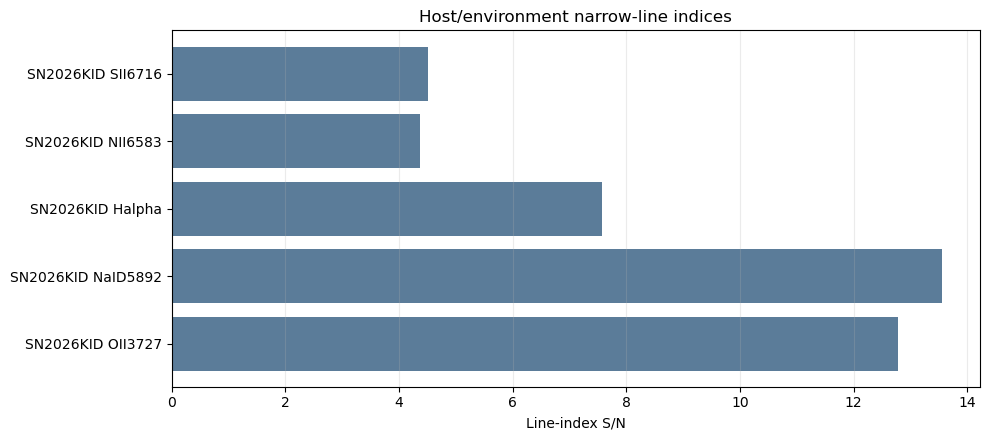

,target,n_detected_host_lines,detected_lines,balmer_decrement_Ha_Hb,rough_EBV_host_mag,host_note
0,SN2026KID,10,"Halpha, NII6583, NaID5892, OII3727, SII6716",NaN,NaN,rough index from SN spectra; verify before phy...


,target,file,date_obs,phase_days,type,z,line,rest_wave,status,snr,flux_index,pEW_A
0,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,OII3727,3727.0,detected,6.573666,1.846697e-13,15.966791
1,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,Hbeta,4861.3,weak/non-detection,-0.057166,-3.647327e-15,0.000000
2,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,OIII4959,4958.9,weak/non-detection,0.896365,-7.812433e-16,0.041247
3,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,OIII5007,5006.8,weak/non-detection,1.855951,-1.283044e-16,0.082608
4,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,NaID5892,5892.0,detected,9.941616,-1.184353e-14,1.519289
5,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,Halpha,6562.8,detected,7.578076,1.224745e-14,1.537511
6,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,NII6583,6583.4,detected,4.360565,5.433751e-15,0.681377
7,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,SII6716,6716.4,detected,4.503041,4.084231e-15,0.516626
8,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,SII6731,6730.8,weak/non-detection,2.584751,9.094550e-16,0.120010
9,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,2026-04-27 15:05:27,NaN,SN II,0.001701,OII3727,3727.0,detected,12.774911,2.888344e-15,2.369745


In [34]:
host_line_fig = snt.plot_host_line_grid(host_lines, target=DIAGNOSTIC_TARGET, fig_dir=FIG_DIR, save_figures=SAVE_FIGURES, filename_tag=RUN_TAG)
snt.show_figure(host_line_fig)
display(host_summary)
display(host_lines)

## 16. 单条谱线局部检查图

改 `CHECK_TARGET`、`CHECK_LINE`、`CHECK_SPECTRUM_INDEX`，或回到配置区改 `LINE_PARAM_OVERRIDES` 后重新运行。

图中：

- 灰色：局部原始光谱。
- 黑色：平滑后的真实观测谱线轮廓。
- 橙色：局部线性连续谱。
- 紫色：第 7 节实际用于测量的高斯吸收轮廓。
- 灰虚线：旧的极值位置，仅作对照。
- 红虚线：谱线静止波长；绿虚线：高斯中心。

方法说明：这张图是第 7 节单条谱线测量的放大复核。连续谱为局部线性模型，紫色为第 7 节同一个高斯拟合结果，pEW 仍来自连续谱与平滑谱之间的直接积分；灰虚线给出旧的极值位置，便于对照。

,spectrum_index,target,date_obs,file,z,type
0,0,SN2026KID,2026-04-26 13:42:30,data/SN2026kid/SN2026kid_bfosc_20260426.fits,0.001701,SN II
1,1,SN2026KID,2026-04-27 15:05:27,data/SN2026kid/SN2026kid_bfosc_20260427.fits,0.001701,SN II
2,2,SN2026KID,2026-05-08 16:27:20,data/SN2026kid/SN2026kid_bfosc_20260508.fits,0.001701,SN II


line check target=SN2026KID, spectrum_index=0, line=Halpha
file = data/SN2026kid/SN2026kid_bfosc_20260426.fits
z = 0.0017010039830893664 (manual)
saved /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/figures/line_check_SN2026KID_SN2026kid_bfosc_20260426_Halpha.png


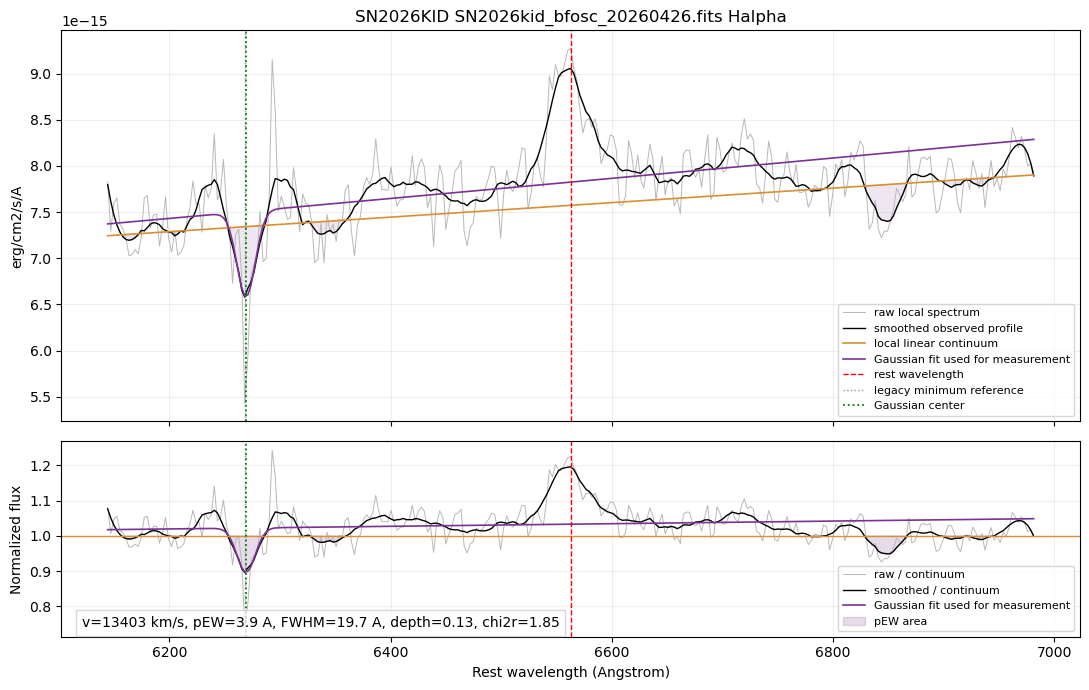

,target,file,date_obs,phase_days,type,z,line,line_label,rest_wave,fit_method,...,FWHM_err_A,depth,fit_center_err_A,fit_sigma_A,fit_sigma_err_A,fit_depth_err,fit_chi2_red,extrema_wave_A,extrema_depth,status
0,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,NaN,SN II,0.001701,Halpha,H alpha,6562.8,gaussian_absorption,...,2.362692,0.125563,0.974327,8.348635,1.003343,0.012813,1.848696,6268.218118,0.104019,ok


In [35]:
# Force fresh plotting/fit code; stale notebook kernels can keep the old broad-Gaussian fitter.
sp = reload(sp)
snt = reload(snt)

CHECK_TARGET_LOCAL = summary.iloc[0]["target"] if CHECK_TARGET is None else CHECK_TARGET
CHECK_LINE_KEY = "Halpha"  # 例如 "Halpha"；None 表示优先使用当前光谱里 qc=adopt/check 的第一条线
CHECK_SPECTRUM_INDEX = 0  # 先看下面的 spectrum_index 表，再改这里选择第几条光谱

display(snt.spectrum_choice_table(spectra, CHECK_TARGET_LOCAL))
check_items = sorted(
    [spec for spec in spectra if spec["target"] == snt.target_key(CHECK_TARGET_LOCAL)],
    key=lambda spec: pd.Timestamp.max if pd.isna(spec["date_obs"]) else spec["date_obs"],
)
check_spec = check_items[int(CHECK_SPECTRUM_INDEX)]
if CHECK_LINE_KEY is None:
    checked = line_qc[
        line_qc["target"].eq(snt.target_key(CHECK_TARGET_LOCAL))
        & line_qc["file"].eq(check_spec["file"])
        & line_qc["status"].eq("ok")
        & line_qc["qc_flag"].isin(["adopt", "check"])
    ].copy()
    if not checked.empty:
        checked["qc_order"] = checked["qc_flag"].map({"adopt": 0, "check": 1}).fillna(2)
        CHECK_LINE_KEY = checked.sort_values(["qc_order", "line"]).iloc[0]["line"]
    else:
        CHECK_LINE_KEY = snt.line_keys_for(check_spec, TARGET_LINES)[0]

print(f"line check target={snt.target_key(CHECK_TARGET_LOCAL)}, spectrum_index={CHECK_SPECTRUM_INDEX}, line={CHECK_LINE_KEY}")
print(f"file = {check_spec['file']}")
print(f"z = {check_spec.get('z')} ({check_spec.get('z_source')})")
if not np.isfinite(check_spec.get("z", np.nan)):
    print("WARNING: 当前光谱还没有采用红移；静止系谱线窗口和绿线位置不能用于科学判断。请先在 REDSHIFT_MEASUREMENTS 填入第 4 节确认的宿主窄线红移。")

check_result, check_fig = snt.plot_line_check(
    spectra,
    target=CHECK_TARGET_LOCAL,
    line_key=CHECK_LINE_KEY,
    spectrum_index=CHECK_SPECTRUM_INDEX,
    fig_dir=FIG_DIR,
    save_figures=SAVE_FIGURES,
    **measure_kwargs,
)
snt.show_figure(check_fig)
display(check_result)

## 17. 保存 CSV 汇总

方法说明：本节只把前面已经算出的表格写入 CSV，不运行新的拟合或重新测量。输出文件会使用 `RUN_TAG`，例如 `SN2026KID_line_diagnostics_qc.csv`；同一目标重跑会覆盖同一目标文件，但不会覆盖其他目标。

In [36]:
def output_path(name):
    ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
    return snt.analysis_output_path(ANALYSIS_DIR, name, tag=RUN_TAG, product_prefix=PRODUCT_PREFIX)


if SAVE_PRODUCTS:
    outputs = {
        "spectra_summary": output_path("spectra_summary.csv"),
        "line_diagnostics_raw": output_path("line_diagnostics_raw.csv"),
        "line_diagnostics_qc": output_path("line_diagnostics_qc.csv"),
        "blackbody_temperature": output_path("blackbody_temperature.csv"),
        "host_environment_lines": output_path("host_environment_lines.csv"),
        "host_environment_summary": output_path("host_environment_summary.csv"),
        "target_status": output_path("target_status.csv"),
        "manual_redshift_measurements": output_path("manual_redshift_measurements.csv"),
        "manual_redshift_summary": output_path("manual_redshift_summary.csv"),
        "skipped_fits": output_path("skipped_fits.csv"),
    }
    summary.to_csv(outputs["spectra_summary"], index=False)
    line_df.to_csv(outputs["line_diagnostics_raw"], index=False)
    line_qc.to_csv(outputs["line_diagnostics_qc"], index=False)
    bb_df.to_csv(outputs["blackbody_temperature"], index=False)
    host_lines.to_csv(outputs["host_environment_lines"], index=False)
    host_summary.to_csv(outputs["host_environment_summary"], index=False)
    target_status.to_csv(outputs["target_status"], index=False)
    redshift_table.to_csv(outputs["manual_redshift_measurements"], index=False)
    redshift_summary.to_csv(outputs["manual_redshift_summary"], index=False)
    skipped_fits.to_csv(outputs["skipped_fits"], index=False)
    for label, path in outputs.items():
        print(f"{label}: {path}")
else:
    print("SAVE_PRODUCTS=False，未写出 CSV。")

spectra_summary: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/SN2026KID_spectra_summary.csv
line_diagnostics_raw: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/SN2026KID_line_diagnostics_raw.csv
line_diagnostics_qc: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/SN2026KID_line_diagnostics_qc.csv
blackbody_temperature: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/SN2026KID_blackbody_temperature.csv
host_environment_lines: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/SN2026KID_host_environment_lines.csv
host_environment_summary: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/SN2026KID_host_environment_summary.csv
target_status: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/analysis_pipeline/SN2026KID_target_status.csv
manual_redshift_measureme

## 18. 下一步人工确认

方法说明：本节不做拟合，只列出需要人工检查和后续采用的结果。

正式报告里建议只引用：

1. 由宿主窄线手动测得并写入 `REDSHIFT_MEASUREMENTS` 的红移；
2. `qc_flag=adopt` 的自动测量；
3. 或者经过上面局部检查图确认后的 `qc_flag=check` 测量。

如果某条线的高斯中心仍然落到错误吸收谷，优先在配置区用 `LINE_PARAM_OVERRIDES` 调整 `half_width`、`smooth_window`、`edge_fraction`，然后重新运行批量测量之后的 cells。